# **Part 1 — Naïve Bayes Theory**

### 1. What is Bayes' Theorem?
Bayes' Theorem calculates the probability of a hypothesis given observed evidence.

In text classification:
- P(class | words) = probability of a class given the words in the document
- P(words | class) = probability of seeing those words in that class
- P(class) = how common that class is overall

### 2. What does "Naïve" mean?
Naïve Bayes assumes all features (words) are **independent** of each other.
In reality, words are correlated — "deep" often appears with "learning".
The model ignores this and treats every word separately. That's the "naïve" assumption.

### 3. Why does it still work well?
Despite the wrong independence assumption, Naïve Bayes works well because:
- Text data is high dimensional — independence assumption reduces noise
- It needs very little training data to estimate probabilities
- It is extremely fast to train and predict
- It performs surprisingly well on real-world text classification tasks

### 4. What is Laplace Smoothing?
If a word never appeared in training for a class, its probability = 0.
This makes the entire prediction 0 (zero probability problem).
Laplace smoothing adds a small value (alpha) to every word count to avoid this.

alpha=1.0 → standard smoothing (default)
alpha=0.1 → less smoothing, model trusts training data more

### 5. MultinomialNB vs GaussianNB vs BernoulliNB

| Model | Input | Best For |
|---|---|---|
| MultinomialNB | Word counts / TF-IDF scores | **Text classification** |
| GaussianNB | Continuous features (normal distribution) | Numerical data |
| BernoulliNB | Binary features (word present or not) | Short texts, spam |

**Best for text: MultinomialNB**
TF-IDF produces non-negative counts/scores → MultinomialNB handles
these naturally and models word frequency which is key for topic classification.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)

sns.set_theme(style='whitegrid')

# **Part 2: Load & Explore**

In [4]:
df = pd.read_csv("final_dataset.csv")

In [9]:
df.head()

,clean_text,label,word_count,raw_token_count,stopwords_removed
0,artificial intelligence ai intelligence demons...,Artificial Intelligence,79,114,35
1,machine learning field artificial intelligence...,Artificial Intelligence,71,93,22
2,deep learning subset machine learning based ar...,Artificial Intelligence,75,97,22
3,neural network computational model inspired st...,Artificial Intelligence,69,93,24
4,natural language processing branch ai enables ...,Artificial Intelligence,77,94,17


In [5]:
df.shape

(60, 5)

In [6]:
df.columns.tolist()

['clean_text', 'label', 'word_count', 'raw_token_count', 'stopwords_removed']

In [7]:
df['label'].value_counts()

,count
label,
Artificial Intelligence,15
Space Exploration,15
Human Biology,15
Famous Scientists,15


In [8]:
df[['clean_text','label']].isnull().sum()

,0
clean_text,0
label,0


/tmp/ipykernel_466/631262657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2', ax=axes[0])


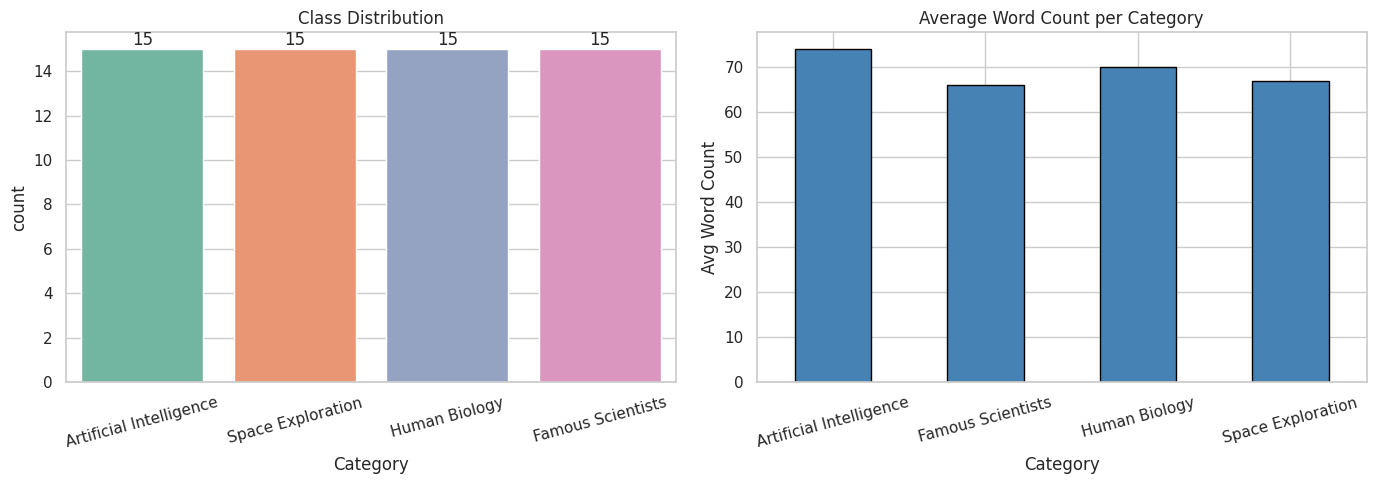

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='label', palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Category')
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# Word count per class
df.groupby('label')['word_count'].mean().plot(kind='bar', color='steelblue',
                                               ax=axes[1], edgecolor='black')
axes[1].set_title('Average Word Count per Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg Word Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# **Part 3: Model Building**

In [12]:
X = df['clean_text']
y = df['label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
(X_train.shape[0])

48

In [18]:
(X_test.shape[0])

12

In [20]:
(y_train.value_counts())

,count
label,
Human Biology,12
Space Exploration,12
Artificial Intelligence,12
Famous Scientists,12


In [21]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('model', MultinomialNB(alpha=1.0))
    ])

In [23]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('model', MultinomialNB())])

In [24]:
y_pred = pipeline.predict(X_test)

In [25]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 1.0000


# **Part 4: Evaluation**

In [27]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0000
Classification Report:
                         precision    recall  f1-score   support

Artificial Intelligence       1.00      1.00      1.00         3
      Famous Scientists       1.00      1.00      1.00         3
          Human Biology       1.00      1.00      1.00         3
      Space Exploration       1.00      1.00      1.00         3

               accuracy                           1.00        12
              macro avg       1.00      1.00      1.00        12
           weighted avg       1.00      1.00      1.00        12



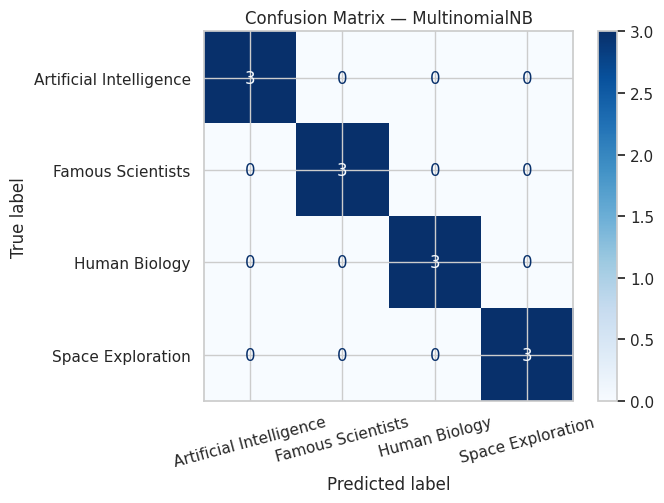

In [29]:
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=pipeline.classes_)
disp.plot(cmap='Blues', xticks_rotation=15)
plt.title('Confusion Matrix — MultinomialNB')
plt.show()

# **Part 5: Model Understanding**

In [31]:
tfidf     = pipeline.named_steps['tfidf']
nb_model  = pipeline.named_steps['model']

In [32]:
features  = tfidf.get_feature_names_out()
classes   = nb_model.classes_

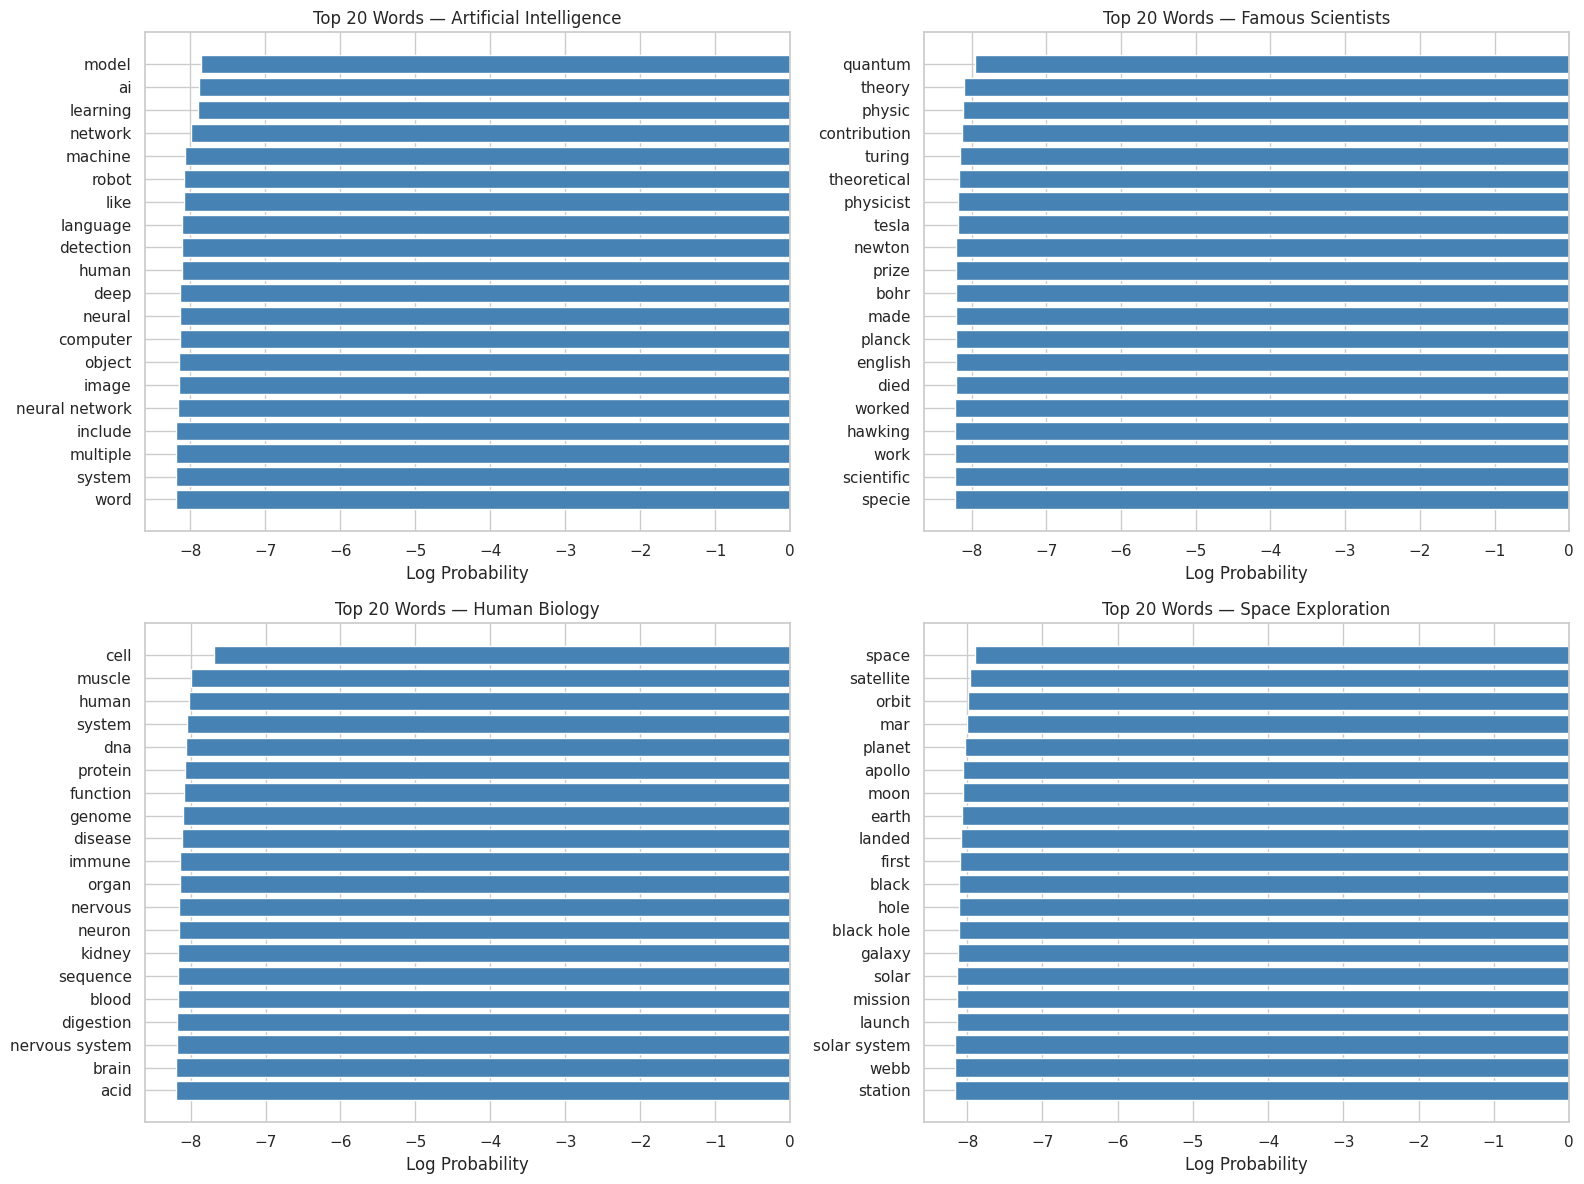

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    log_probs  = nb_model.feature_log_prob_[idx]
    top20_idx  = log_probs.argsort()[-20:][::-1]
    top20_words= [features[i] for i in top20_idx]
    top20_probs= [log_probs[i] for i in top20_idx]

    axes[idx].barh(top20_words[::-1], top20_probs[::-1], color='steelblue')
    axes[idx].set_title(f'Top 20 Words — {cls}')
    axes[idx].set_xlabel('Log Probability')

plt.tight_layout()
plt.show()

In [37]:
y_proba = pipeline.predict_proba(X_test)
max_probs = y_proba.max(axis=1)

results = pd.DataFrame({
    'text'      : X_test.values,
    'true_label': y_test.values,
    'pred_label': y_pred,
    'confidence': max_probs
})

print("5 MOST CONFIDENT PREDICTIONS")
top5 = results.nlargest(5, 'confidence')
for _, row in top5.iterrows():
    print(f"True: {row['true_label']:<25} Pred: {row['pred_label']:<25} Conf: {row['confidence']:.4f}")

print("\n5 LEAST CONFIDENT PREDICTIONS")
bot5 = results.nsmallest(5, 'confidence')
for _, row in bot5.iterrows():
    print(f"True: {row['true_label']:<25} Pred: {row['pred_label']:<25} Conf: {row['confidence']:.4f}")

5 MOST CONFIDENT PREDICTIONS
True: Artificial Intelligence   Pred: Artificial Intelligence   Conf: 0.4523
True: Artificial Intelligence   Pred: Artificial Intelligence   Conf: 0.4449
True: Famous Scientists         Pred: Famous Scientists         Conf: 0.4373
True: Space Exploration         Pred: Space Exploration         Conf: 0.4219
True: Artificial Intelligence   Pred: Artificial Intelligence   Conf: 0.4181

5 LEAST CONFIDENT PREDICTIONS
True: Space Exploration         Pred: Space Exploration         Conf: 0.3488
True: Famous Scientists         Pred: Famous Scientists         Conf: 0.3545
True: Human Biology             Pred: Human Biology             Conf: 0.3633
True: Space Exploration         Pred: Space Exploration         Conf: 0.3670
True: Human Biology             Pred: Human Biology             Conf: 0.3749


In [38]:
for alpha in [1.0, 0.1]:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('model', MultinomialNB(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    print(f"alpha={alpha} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

alpha=1.0 → Accuracy: 1.0000 | F1: 1.0000
alpha=0.1 → Accuracy: 1.0000 | F1: 1.0000


# **Part 6: Model Comparison**

In [39]:
models = {
    'MultinomialNB'  : MultinomialNB(alpha=1.0),
    'BernoulliNB'    : BernoulliNB(alpha=1.0),
    'ComplementNB'   : ComplementNB(alpha=1.0)
}

results_list = []

for name, model in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    results_list.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1})
    print(f"{name:<20} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

results_df = pd.DataFrame(results_list)

MultinomialNB        → Accuracy: 1.0000 | F1: 1.0000
BernoulliNB          → Accuracy: 1.0000 | F1: 1.0000
ComplementNB         → Accuracy: 1.0000 | F1: 1.0000


In [40]:
results_df

,Model,Accuracy,F1 Score
0,MultinomialNB,1.0,1.0
1,BernoulliNB,1.0,1.0
2,ComplementNB,1.0,1.0


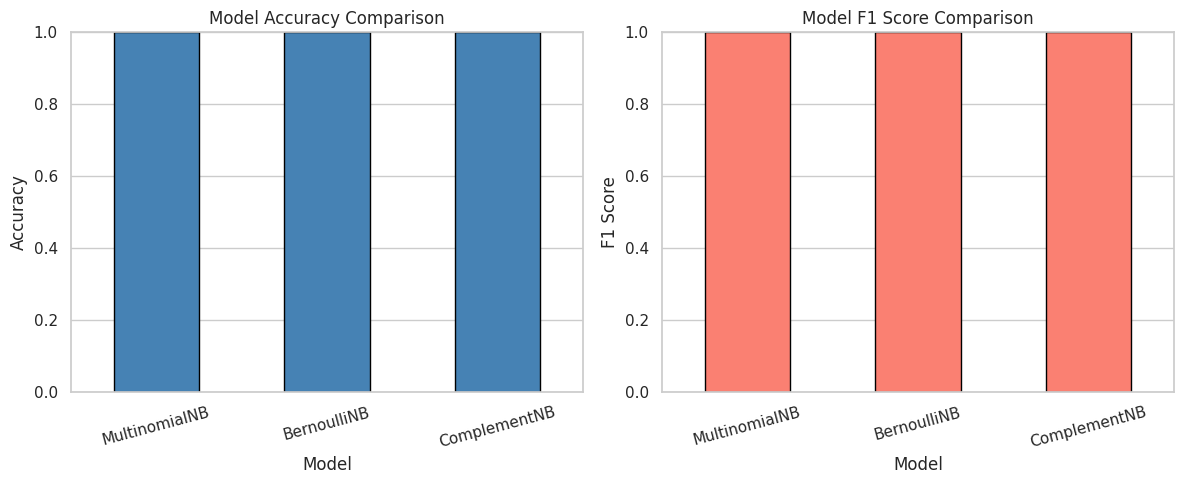


Best Model:
Model       MultinomialNB
Accuracy              1.0
F1 Score              1.0
Name: 0, dtype: object


In [41]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
results_df.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0],
                color='steelblue', legend=False, edgecolor='black')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0, 1)

results_df.plot(x='Model', y='F1 Score', kind='bar', ax=axes[1],
                color='salmon', legend=False, edgecolor='black')
axes[1].set_title('Model F1 Score Comparison')
axes[1].set_ylabel('F1 Score')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nBest Model:")
print(results_df.loc[results_df['Accuracy'].idxmax()])